# Analyse de la complexité (Projet Recherche Opérationnelle)

(Importation obsolète, à refaire pour adapter avec les nouveaux csv)

Ce notebook Jupyter permet d'effectuer l'analyse de complexité demandée dans la partie 3 du sujet de projet.
Assurez-vous d'avoir un fichier CSV nommé `donnees_transport.csv` dans le même répertoire.

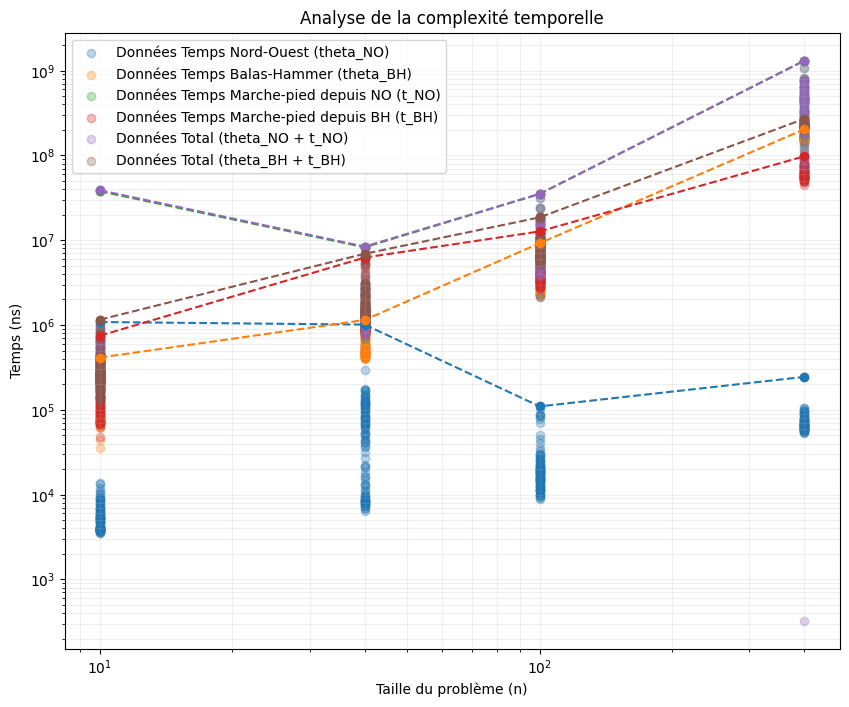

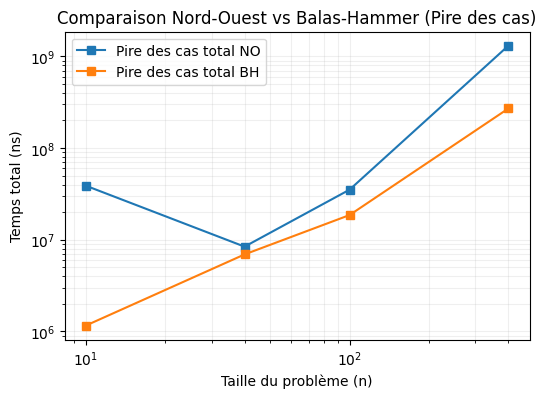

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement des données
df = pd.read_csv('complexite/mesures.csv')

# 2. Préparation : Groupement par taille n pour obtenir le pire des cas (maximum)
# On cherche l'enveloppe supérieure du nuage de points pour chaque n
pire_des_cas = df.groupby('n').max()

# Liste des métriques à analyser selon les consignes
metriques = {
    'thetaNO_ns': 'Temps Nord-Ouest (theta_NO)',
    'thetaBH_ns': 'Temps Balas-Hammer (theta_BH)',
    'tNO_ns': 'Temps Marche-pied depuis NO (t_NO)',
    'tBH_ns': 'Temps Marche-pied depuis BH (t_BH)',
    'totalNO_ns': 'Total (theta_NO + t_NO)',
    'totalBH_ns': 'Total (theta_BH + t_BH)'
}

# 3. Visualisation des nuages de points et des enveloppes supérieures (pire des cas)
plt.figure(figsize=(10, 8))

for col, label in metriques.items():
    plt.scatter(df['n'], df[col], alpha=0.3, label=f'Données {label}')
    plt.plot(pire_des_cas.index, pire_des_cas[col], marker='o', linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Taille du problème (n)')
plt.ylabel('Temps (ns)')
plt.title('Analyse de la complexité temporelle')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# 4. Comparaison directe des algorithmes complets
plt.figure(figsize=(10, 8))
plt.plot(pire_des_cas.index, pire_des_cas['totalNO_ns'], marker='s', label='Pire des cas total NO')
plt.plot(pire_des_cas.index, pire_des_cas['totalBH_ns'], marker='s', label='Pire des cas total BH')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Taille du problème (n)')
plt.ylabel('Temps total (ns)')
plt.title('Comparaison Nord-Ouest vs Balas-Hammer (Pire des cas)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## Conseils pour l'interprétation (Section 3.3.4 & 3.3.5)

1. **Enveloppe supérieure** : La courbe obtenue avec `pire_des_cas` représente l'évolution du temps dans le pire des scénarios pour chaque taille $n$.
2. **Identification** : Si la courbe est une droite en échelle log-log, la pente donne l'exposant de la complexité polynomiale.
3. **Comparaison** : Comparez les résultats de `totalNO_ns` et `totalBH_ns` pour discuter quel algorithme permet une résolution plus efficace.